<a href="https://colab.research.google.com/github/cathdong66-lgtm/EMSC2010-Portfolio/blob/main/emsc2010_week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project Week 9

## 1. Project Overview
Group name: Cloudy with a chance of stats

Project week: 9

Project title: How does Earth's surface temperature change with increasing CO2 emissions?

Datasets used (name and source): NA

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Deadline |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Cathy | Sutton | Yes| 8/5|
| Data steward | Sutton | Leo | Yes| 9/5|
| Analysis / modelling | Leo | Elena | Yes| 11/5|
| Visualisation / interpretation | Elena | Kimi | Yes| 12/5|
| Narrative | Kimi | Sameer | Yes| 13/5|
| Quality Control / Reproducibility  | Sameer | Cathy | Yes| 14/5|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Project Overview**

 This week our group decided to tackle the question of how Earth's surface change with increasing C0$_2$ emissions.  We believed this question best reflected our understanding of numerical simualtion and modelling, and as global CO2 rises, understanding the relationship between C0$_2$ and atmospheric temperature is more important than ever. Utilising our knowledge from this week, we plotted atmospheric temperature against different C0$_2$ emission concentrations to see how it would change. This plot aims to simulate complex real world phenomena in a way that can be simplified and analysed, and is also lightly based of the Shared socioeconomic pathways (SSP). Each of these different pathways were initially built on the Representative Concentration Pathways (RCPs) and inform us on how earths temperature and future societal developments will look depending on the C0$_2$ emissions path we take. Literature and the IPCC 6th edition agree that we are currently on the SSP2 middle of the road pathway, where emissions will remain at its current level before taking a decline in the near future, leaving us an estimated 2.7ºC to 3ºC increase in warming by the end of the century. Using the results produced from this plot, we can gain an elementary understanding on the effects different C0$_2$ emission levels have on atmospheric temperature.

**Data Analysis/Modelling**


In terms of data collection, this question only required values for the Earths energy balance model of which were all derived from the internet. Our initial conditions were set to preindustrial levels for both the  C0$_2$  and the global surface temperature at 280ppm and 286K respectively. To answer the question of how earth's atmospheric temperature changes with increasing  C0$_2$ emission, we employed a numerical model spanning over 300 years and 10 different emission pathways. Within the different scenarios, we started at -3ppm/year and increased by 1ppm for each scenario until we reached +6ppm. This model runs each scenario from the preindustrial level until we reach 300 years to see how temperature change with differing C0$_2$  concentrations. These correspond with RCP emissions scenarios, where each emission pathway produces a distinct radiative forcing and corresponding surface temperature. The equations that were used are highlighted below.

The model used to calculate changing radiative forcing is below:
1) $\Delta$F= α(ln(C/C$_0$))

Where α is a determined constant (5.35), C is CO$_2$ concentration in ppm, and C$_0$ is the preindustrial CO$_2$ level in ppm.

From the radiative forcing, change in temperature can be calculated:

2.  $\Delta$T= λ*$\Delta$F

Where λ is the climate sensitivity parameter (0.8 K/(W/$m^2$)).

Model adapted from Myhre,G. (1998) *New Estimates of Radiate Forcing due to Well MIxed Greenhouse Gases*, AGU. https://doi.org/10.1029%2F98GL01908

In [ ]:
#import packages
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#C0 = 280 #Preindustrial CO2 level (ppm)
#T0 = 286 # Preindustrial Global Surface Temperature (K)
#F = 5.35*np.log(C/C0) #Radiative forcing (W/m^2) - From Myhre 1998
#λ = 0.8 #Climate sensitivy parameter (K/(W/m^2))
#T_c = λ*F #Temperature increase from CO2
#T_a = T0 + T_c #Temp with atmosphere

In [ ]:
# Initialise time step
years = 300 # Length of simulation
nsteps = years # Number of time steps

# Initialise CO2 growth rate and range
growth_rate_range = 10
growth_rate_min = -3 # Minimum growth rate (ppm/year)

# Initialise other constants
C0 = 280 #Preindustrial CO2 level (ppm)
λ = 0.8 #Climate sensitivity parameter (K/(W/m^2))
T0 = 286 # Preindustrial Global Surface Temperature (K)

In [ ]:
# Initialise arrays to store simulation results for each growth rate and time step.
# C: CO2 concentration (ppm)
# F: Radiative forcing (W/m^2)
# T_C: Temperature change due to CO2 (K)
# T_a: Total atmospheric temperature (K)
# Each array is (growth_rate_range x nsteps) to store data for all scenarios.
C = np.zeros((growth_rate_range, nsteps))
F = np.zeros((growth_rate_range, nsteps))
T_C = np.zeros((growth_rate_range, nsteps))
T_a = np.zeros((growth_rate_range, nsteps))

# Create a time array from 0 to nsteps-1, representing years.
time = np.arange(nsteps)

# Define the range of CO2growth rates to simulate
growth_rates = np.arange(growth_rate_min, growth_rate_min + growth_rate_range)

# Main simulation loop: Iterate through each defined CO2 growth rate scenario.
for i in range(growth_rate_range):
  current_growth_rate = growth_rates[i]

  # Set initial CO2 concentration for the current growth rate scenario at time step 0.
  # C0 is the preindustrial CO2 level.
  C[i, 0] = C0
  # Set initial atmospheric temperature for the current growth rate scenario at time step 0.
  # This uses the predefined preindustrial global surface temperature T0.
  T_a[i, 0] = T0

  # Inner loop: Iterate through each time step for the current growth rate scenario.
  # The loop starts from j=1 because j=0 has been set as the initial condition.
  for j in range(1, nsteps):
    # Calculate CO2 concentration for the current step based on the previous step and the current growth rate.
    C[i, j] = C[i, j-1] + current_growth_rate
    # Ensure atmospheric CO$_2$ does not drop below 1 ppm (to prevent errors with log and for realism).
    if C[i, j] < 1:
       C[i, j] = 1
    # Calculate radiative forcing using Myhre 1998 formula.
    # F = 5.35 * ln(C/C0)
    F[i, j] = 5.35 * np.log(C[i, j] / C0)
    # Calculate the temperature change due to CO$_2$ using the climate sensitivity parameter (λ).
    T_C[i, j] = λ * F[i, j]
    # Calculate the total atmospheric temperature for the current step.
    T_a[i, j] = T0 + T_C[i, j]

## After writing the code and key annotations in this cell I asked Gemini to annotate it.
## It expanded on my key annotations and suggested comments on the rest of, which I read over and approved.

**Data Interpretation & Visualization**

For the visualisation section, we were able to plot a singular graph visualising the atmospheric temperature over time for different growth rates. We were able to do this by placing plotting commands within the simulation loop, which was done so that they would simultaneously plot the corresponding temperature data as the loop iterated through each CO$_2$ growth-rate scenario.

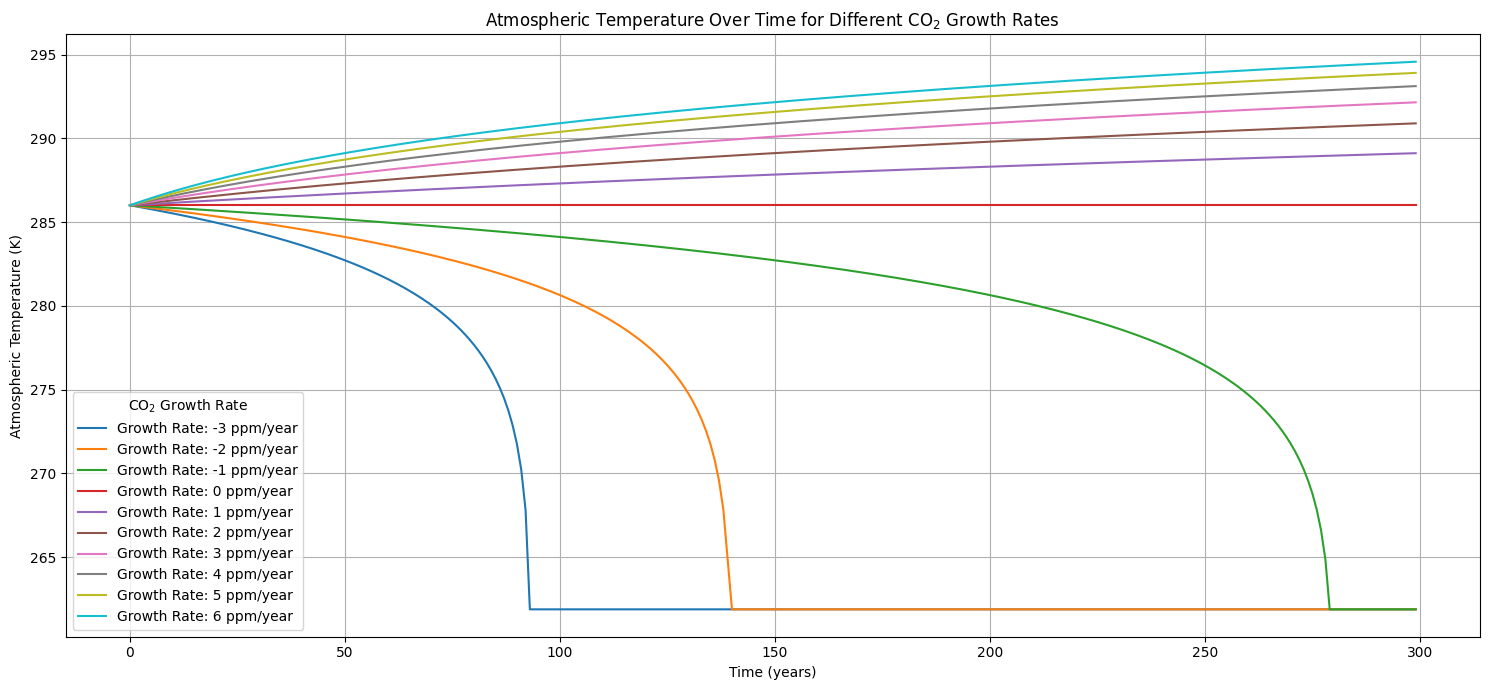

In [ ]:
# plotting atmospheric temperature
plt.figure(figsize=(15, 7))

for i in range(growth_rate_range): # places the plotting commands within the simulation loop
  plt.plot(time, T_a[i], label=f'Growth Rate: {growth_rates[i]} ppm/year')

plt.title(r'Atmospheric Temperature Over Time for Different CO$_2$ Growth Rates')
plt.xlabel('Time (years)')
plt.ylabel('Atmospheric Temperature (K)')
plt.legend(title=r'CO$_2$ Growth Rate')
plt.grid(True)

plt.tight_layout()
plt.show()

**Interpretation**

As observed in the graph above, the key distinguishing parameter between each scenario is the growth rate of the CO$_2$, resulting in different temperatures depending on the size of the growth rate. When the CO$_2$ is decreasing, this causes temperature to decrease overtime until it reaches a threshold where it flatlines. Differences between the decreasing scenarios are quite larger, and are also proportionally larger than if we were to increase. Conversely, increasing CO$_2$ growth rates produce an increase in atmospheric temperature, which is consistent with the greenhouse effect. Increasing CO$_2$ emissions enhance the greenhouse effect, trapping more of the sun's outgoing longwave radiation which then causes an overall warmer atmospheric temperature. We can see that the larger  CO$_2$ growth rates e.g( 4, 5 and 6ppm/year) cause an overall warmer atmospheric temperature, but at a certain point the differences in temperatures between these larger growth rates get narrower. These results that were obtained are consistent with what is observed in the logic that underlies the IPCC's SSPs, where differences between the high emissions scenarios begin to diminish.

While our plot captures the overall idea of the climate systems response to rising CO2 emissions, it is important to acknowledge that this is an extremely simplified model of how the climate works and that it does not consider many of the  background climate dynamics and feedback loops that also determine how the atmosphere responds to CO2 emissions. Despite such limitations, these results still produce meaningful implications of the nature and sensitivity of the climate system. The numerical simulation shows that even little amounts of change in CO2 have the capability of producing a difference in the atmospheric temperature, reflecting a simple yet insightful understanding of the current climate situation. The plot demonstrates that the earths surface and atmospheric temperatures are highly dependent ton future emission pathways, much like how the IPPC has demonstrated to us from the SSPs, where there are predicted differing societal outcomes depending on the emissions pathway we take. In the high emissions scenarios (SSP5) where we heavily rely on fossil fuels and make no effort to reduce our emissions we can see a temperature increase of about 4.4ºC or higher and social chaos. But if we decide to take a low emissions route (SSP1) we can expect to see tough restrictions on the use of fossil fuels and a shift towards sustainable practices, leading to an overall 1.5ºC of warming by the time we reach 2100. The current projection of SSP2, we will expect to see a global temperature rise of 2.7ºC by 2100. Overall, these results can prompt us to do further research in this area by adding more complex climate dynamics to quantify the full nature of this relationship and can support policy making to ensure we do not fall into a path of no return.

# **Reflections**

**Cathy**

This week I was responsible for setting up the group GitHub repository and colab. This meant I polished up the project overview, roles and contributions and reflections, as well as clean up the repository such as removing the inital group project template after I made the final commit to GitHub. There was an error on my part when it came to initially sharing the colab link with the incorrect permissions to edit. I rectified this in time so Leo had enough time to do his part before his deadline. Doing this role has solidified by skills on how to create a colab that can be edited on by other people, as well as cleaning the repository to make it presentable for viewing.

**Sutton**


This week I had the role of data steward where I had to research and find a simple one atmosphere climate model as well as the model parameters to use. Our aim was to model the effect of carbon dioxide radiative forcing upon the global surface temperature. After some research I found a model and parameters in a paper by Myhre,G frtom 1998 and adapted it to todays conditions. This week allowed me to learn how I can find pre-developed models and adapt them easily to solve related problems.

**Leo**

In my role as analysis/modelling lead this week, I took the formula and constants provided by Sutton and utilised a loop to implement a model over time. This predicted temperature over a time period accounting for a constant increase of CO2. I decided this was a bit simple and added an further step to the code, implementing the model over a range of increasing rates of CO2. This presented a couple of additional challenges: I had to make the arrays to store the values two dimensional to accomodate running the model multiple times under different CO2 forcings and with the addition of a negative CO2 emissions rate, I had to introduce an if statement to ensure that total atmospheric CO2 did not drop below 1ppm and break the formula (which included a log(CO2)).

**Elena**

This week as the person in charge of visualisation and interpretation, I was able to effectively communicate with my team members about how best to display this information. There was a slight glitch with the whole document not running, but through quick communication this issue was resolved. The trickiest part was figuring out how to account for the different levels of CO2, but through simple array indexing and a for loop, I was able to implement this improvement made by Leo. Part of the job was also cleaning up the graphs' titles, axes, and labels, which I had to delve back through the weeks of learning to achieve. These graphs are not perfect real-world models, but can give us a good start into investigating how one element can affect atmospheric temperature.

**Kimi**

This week, my role of narrative required me to peice each of the parts together through giving a worded summary of each of the components of the colab notebook. I found this quite insightful as it required me to truly understand the question that we were answering and the code that went into producing the outputs, of which none of my previous roles had done yet. This role was made easy from the comments and annotations of those that were in the data analysis and visualisation roles. Narrative's in the preivous colab notebooks provided a helpful idea of what was required of me to write in this section. I found that this weeks questions was quite straightforward and easy to link to real world implications. Overall, this weeks group project provided me with a deeper understanding of numercial modelling and how it can help us understand real world scenarios in a somewhat simplified way.

**Sameer**

As the Quality Control / Reproducibility Lead, my primary focus this week was to ensure the integrity and clarity of our project notebook. This involved meticulously checking that the entire notebook could run seamlessly from top to bottom without any errors, which included verifying all code cells executed correctly and in the intended sequence. I reviewed the generated figures and outputs to confirm they accurately represented the data and analysis, and that their presentation was clear and insightful.This role provided valuable experience in the critical importance of meticulous review and clear communication in scientific projects.